# DATA VISUALIZATION

# LINE CHART

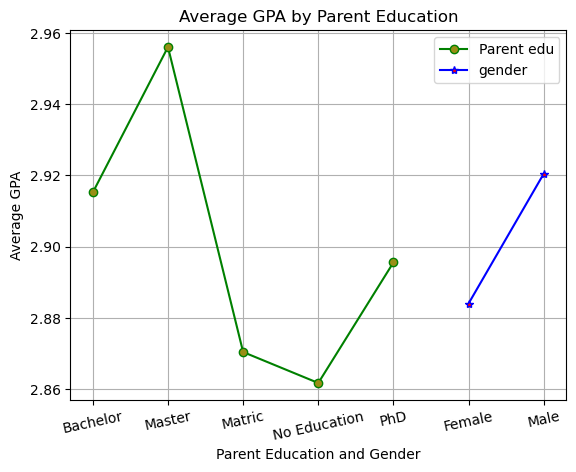

In [27]:
group_mean = df.groupby('parent_edu')['gpa'].mean()
gender_mean = df.groupby('gender')['gpa'].mean()
plt.plot(group_mean.index, group_mean.values, marker='o',color='green', markerfacecolor='#998E15',label='Parent edu')
plt.plot(gender_mean.index, gender_mean.values, marker='*',color='blue', markerfacecolor='red',label='gender')
plt.xlabel("Parent Education and Gender")
plt.ylabel("Average GPA")
plt.title("Average GPA by Parent Education")
plt.xticks(rotation=12)
plt.grid(True)
plt.legend()
plt.show()

# SCATTER PLOT

In [29]:
rep = df['parent_edu'].replace({'Bachelor':0,'Master':1,'Matric':2,'No Education':3,'PhD':4})

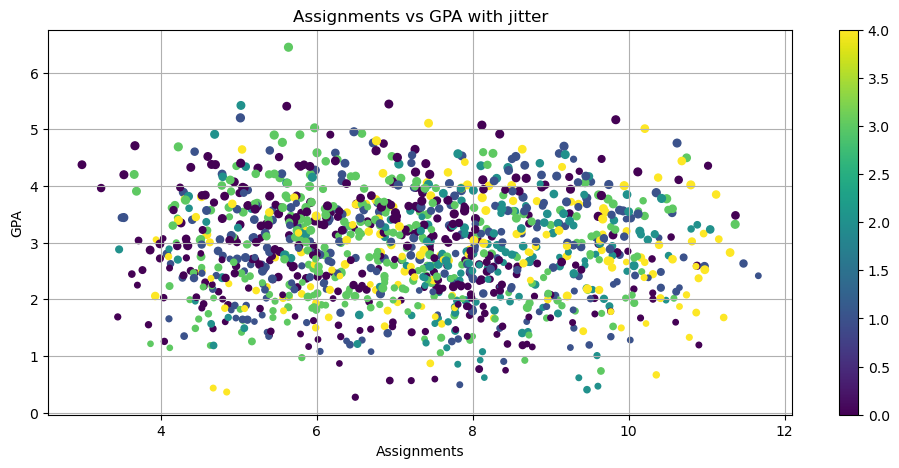

In [30]:
x_jitter = df['assignments'] + np.random.normal(0, 0.7, size=len(df))
y_jitter = df['gpa'] + np.random.normal(0, 0.7, size=len(df))

plt.figure(figsize=(12,5))
plt.scatter(x_jitter, y_jitter, c=rep, s=df['gpa']*8)
plt.xlabel("Assignments")
plt.ylabel("GPA")
plt.title("Assignments vs GPA with jitter")
plt.colorbar()
plt.grid()
plt.show()


# BAR CHARTS

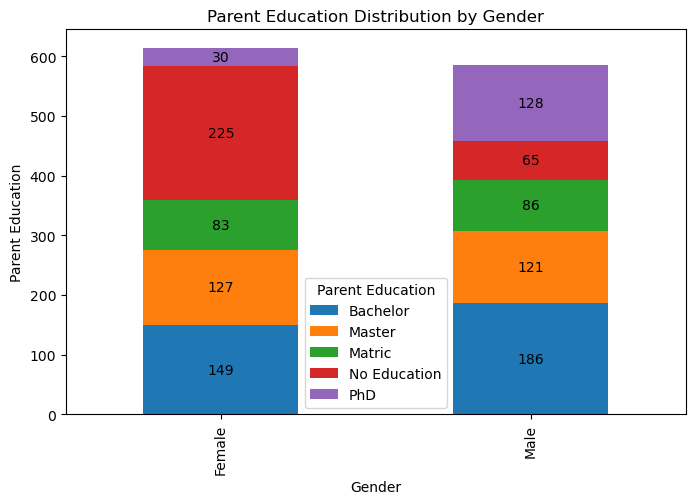

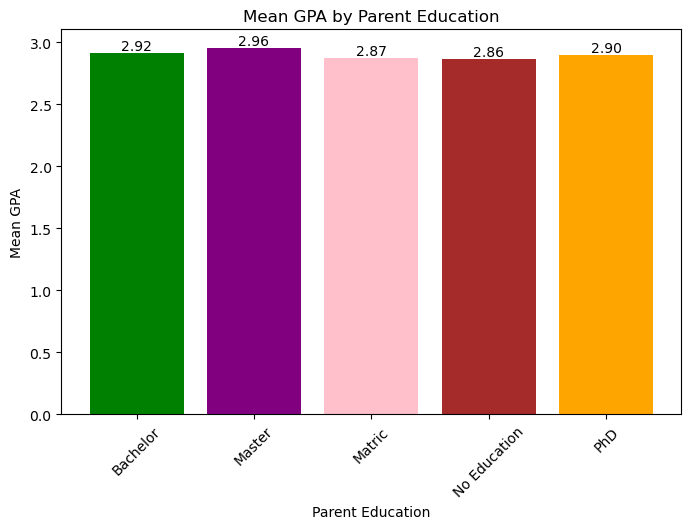

In [34]:
count_data = df.groupby(['gender', 'parent_edu']).size().unstack(fill_value=0)
ax = count_data.plot(kind='bar', stacked=True, figsize=(8,5))
for c in ax.containers:
    ax.bar_label(c, label_type='center')
plt.xlabel("Gender")
plt.ylabel("Parent Education")
plt.title("Parent Education Distribution by Gender")
plt.legend(title="Parent Education")


mean_gpa = df.groupby('parent_edu')['gpa'].mean()
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(mean_gpa.index, mean_gpa.values, color=['green','purple','pink','brown','orange'])
ax.bar_label(bars, fmt="%.2f")

ax.set_xlabel("Parent Education")
ax.set_ylabel("Mean GPA")
ax.set_title("Mean GPA by Parent Education")
plt.xticks(rotation=45)
plt.show()

In [35]:
temp_df = df[df['parent_edu'].isin(['Bachelor','Master','Matric'])].pivot_table(index='assignments',columns='parent_edu',values='gpa')
fig3 = px.bar(temp_df,x=temp_df.index,y=temp_df.columns,barmode='group')
fig3.write_html("graph3.html", include_plotlyjs='cdn')
fig3

# PIE CHARTS

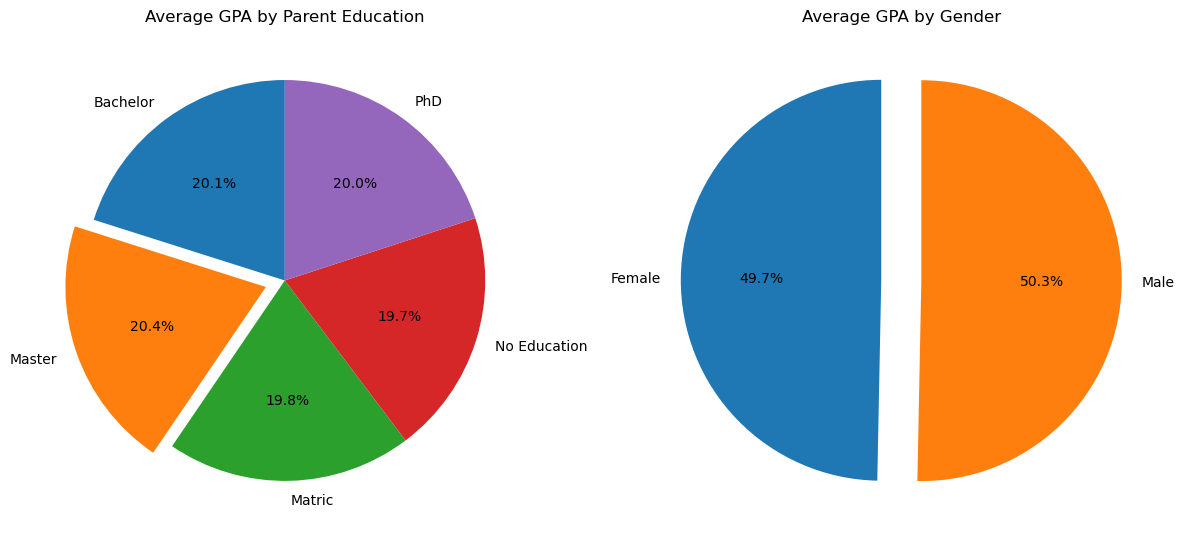

In [36]:
parent_gpa = df.groupby('parent_edu')['gpa'].mean()

gender_gpa = df.groupby('gender')['gpa'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].pie(parent_gpa, labels=parent_gpa.index, autopct='%1.1f%%', startangle=90,explode=[0,0.1,0,0,0])
axes[0].set_title("Average GPA by Parent Education")

axes[1].pie(gender_gpa, labels=gender_gpa.index, autopct='%1.1f%%', startangle=90,explode=[0.1,0.1])
axes[1].set_title("Average GPA by Gender")

plt.tight_layout()
plt.show()

# HISTOGRAMS

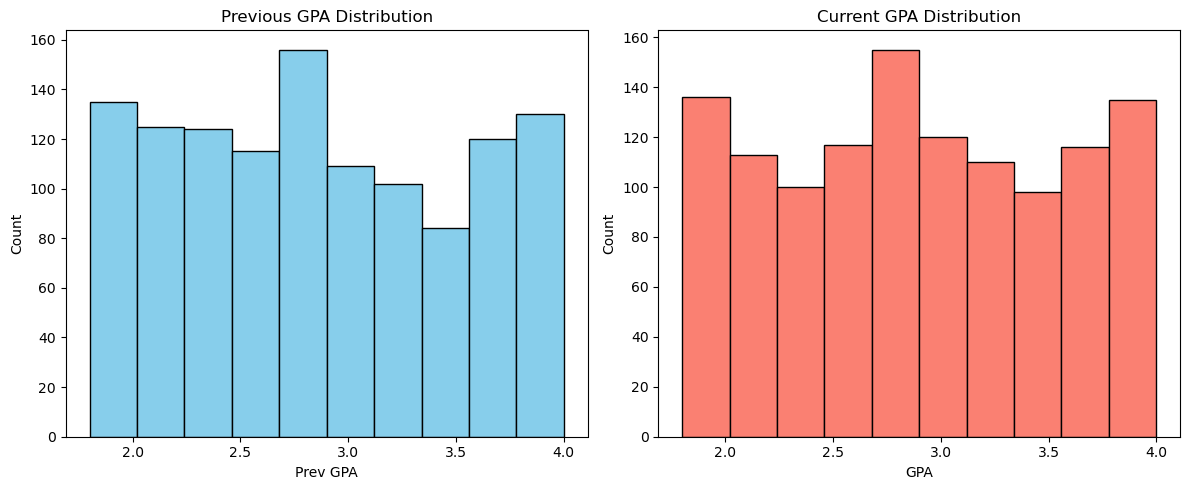

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(df['prev_gpa'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_title("Previous GPA Distribution")
axes[0].set_xlabel("Prev GPA")
axes[0].set_ylabel("Count")

axes[1].hist(df['gpa'], bins=10, color='salmon', edgecolor='black')
axes[1].set_title("Current GPA Distribution")
axes[1].set_xlabel("GPA")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


# HEATMAP

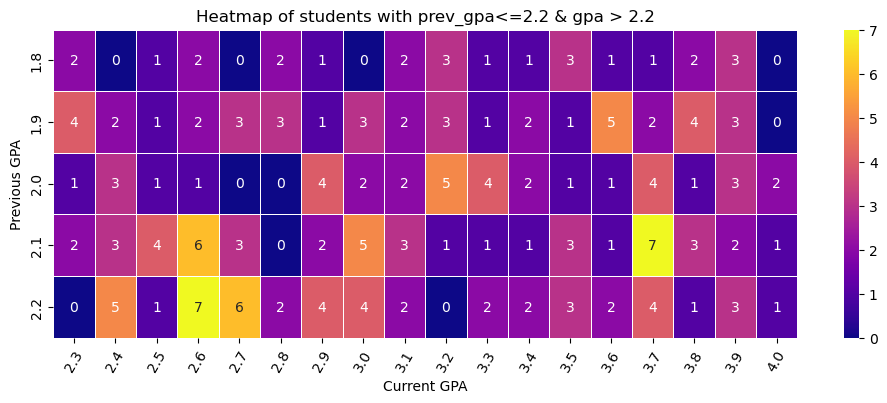

In [38]:
#Heatmap is where we convert a grid into graph and that graph show how the values are distrubuted
filtered_df = df[(df['prev_gpa'] <= 2.2) & (df['gpa'] > 2.2)]
pivot_table = filtered_df.pivot_table(index='prev_gpa', columns='gpa', aggfunc='size', fill_value=0)

plt.figure(figsize=(12,4))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap="plasma", cbar=True, linewidths=0.5, linecolor='white')
plt.title("Heatmap of students with prev_gpa<=2.2 & gpa > 2.2")
plt.xlabel("Current GPA")
plt.ylabel("Previous GPA")
plt.xticks(rotation=60)
plt.show()
